# CRRT Prediction EDA
Analyzes synthetic dataset used to train model. 

In [9]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# add src/ to path so import preprocessing utilities
sys.path.insert(0, str(Path('..') / 'src'))
from preprocessing import engineer_features, FEATURE_COLS, TARGET_COL

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Load raw data
raw_df = pd.read_csv('../data/synthetic_data.csv')
# Run the same feature engineering the model pipeline uses
df = engineer_features(raw_df.copy())

print(f'Raw shape:       {raw_df.shape}')
print(f'Engineered shape: {df.shape}')
print(f'Target column:   {TARGET_COL}')
print(f'Feature columns: {FEATURE_COLS}')


Revised Baux Score feature:
   age  tbsa_2nd_3rd  inhalation_flag  revised_baux_score
0   82            72                1                 171
1   13            11                1                  41
2   82            34                0                 116
3   49            65                1                 131
4    8            26                1                  51

Hours Injury to Admission feature:
      injury_datetime  admission_datetime  hours_injury_to_admission  \
0 2023-09-06 07:53:23 2023-09-06 15:53:23                        8.0   
1 2016-10-14 23:45:05 2016-10-15 17:45:05                       18.0   
2 2019-03-28 16:28:29 2019-03-29 01:28:29                        9.0   
3 2016-09-19 19:17:46 2016-09-21 06:17:46                       35.0   
4 2017-08-18 07:47:20 2017-08-19 11:47:20                       28.0   

   late_admission_flag  
0                    1  
1                    1  
2                    1  
3                    1  
4                    1  

CRR

## 1. Dataset Overview

In [10]:
print('First 5 rows')
display(raw_df.head())
print('column types')
print(raw_df.dtypes.value_counts())
print('numeric summary')
display(raw_df.describe().T.round(2))

First 5 rows


,record_id,age,sex,race,ethnicity,living_situation,marital_status,residence_type,occupation_related_injury,injury_year,...,crrt_25_48h,total_crystalloid_ml_first_24h,total_crystalloid_ml_25_48h,total_colloid_ml_first_24h,total_colloid_ml_25_48h,total_blood_products_units_first_24h,total_blood_products_units_25_48h,total_urine_output_ml_first_24h,total_urine_output_ml_25_48h,discharge_weight_kg
0,1,82,M,White,Non-Hispanic,Assisted Living,Married,Apartment,Yes,2023,...,No,20561,3339,90,0,2,0,1650,1094,92.2
1,2,13,F,Asian,Non-Hispanic,Home,Widowed,House,No,2016,...,No,717,182,0,0,1,0,931,888,39.3
2,3,82,M,Asian,Hispanic,Assisted Living,Single,Shelter,No,2019,...,No,9696,6298,0,0,0,0,1273,1361,70.1
3,4,49,F,Other,Non-Hispanic,Home,Single,Shelter,No,2016,...,No,18143,11274,0,0,2,1,1909,1777,109.6
4,5,8,M,Other,Hispanic,Home,Widowed,House,Yes,2017,...,No,2333,889,0,0,0,0,559,623,22.3


column types
object     38
int64      20
float64     7
Name: count, dtype: int64
numeric summary


,count,mean,std,min,25%,50%,75%,max
record_id,200.0,100.50,57.88,1.00,50.75,100.50,150.25,200.00
age,200.0,44.50,26.80,1.00,19.00,44.50,68.25,90.00
injury_year,200.0,2019.72,2.87,2015.00,2017.00,2020.00,2022.00,2024.00
carboxyhemoglobin,200.0,11.78,7.08,0.10,5.50,11.85,17.73,24.90
initial_gcs,200.0,9.80,3.74,3.00,7.00,10.00,13.00,15.00
initial_temp_c,200.0,36.15,1.28,34.00,35.10,36.00,37.30,38.50
tbsa_2nd_3rd,200.0,46.02,26.65,1.00,21.00,47.00,68.25,95.00
admission_year,200.0,2019.42,2.89,2015.00,2017.00,2019.00,2022.00,2024.00
msdrg,200.0,951.30,27.53,900.00,925.75,951.00,974.25,999.00
lund_browder_percent,200.0,52.77,28.76,1.00,28.50,56.00,75.25,100.00


## 2. Missingness Analysis

7 columns have missing values:


,missing_count,missing_pct
first_wound_excision_datetime,68,34.0
date_of_last_surgery,68,34.0
complication,56,28.0
alcohol_drug_indicator,42,21.0
vte_prophylaxis_start_date,40,20.0
vte_prophylaxis_type,40,20.0
comorbidity,39,19.5


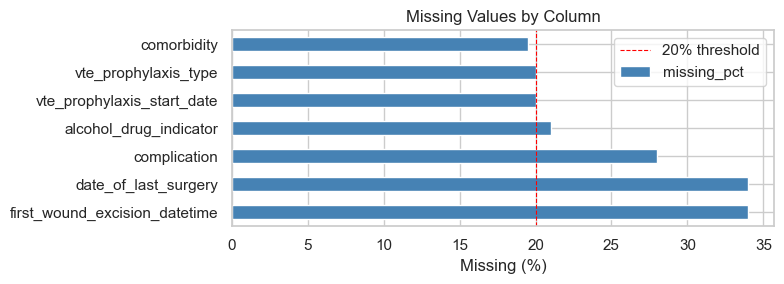

In [11]:
missing = raw_df.isnull().sum()
missing_pct = (missing / len(raw_df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

if missing_df.empty:
    print('No missing values in raw data.')
else:
    print(f'{len(missing_df)} columns have missing values:')
    display(missing_df)

    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_df) * 0.4)))
    missing_df['missing_pct'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    ax.axvline(20, color='red', linestyle='--', linewidth=0.8, label='20% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 3. Target Variable: `crrt_within_48h`
This is the label the model predicts (CRRT needed at any point in the first 48 hours).
Also shown: the two source columns it is derived from.

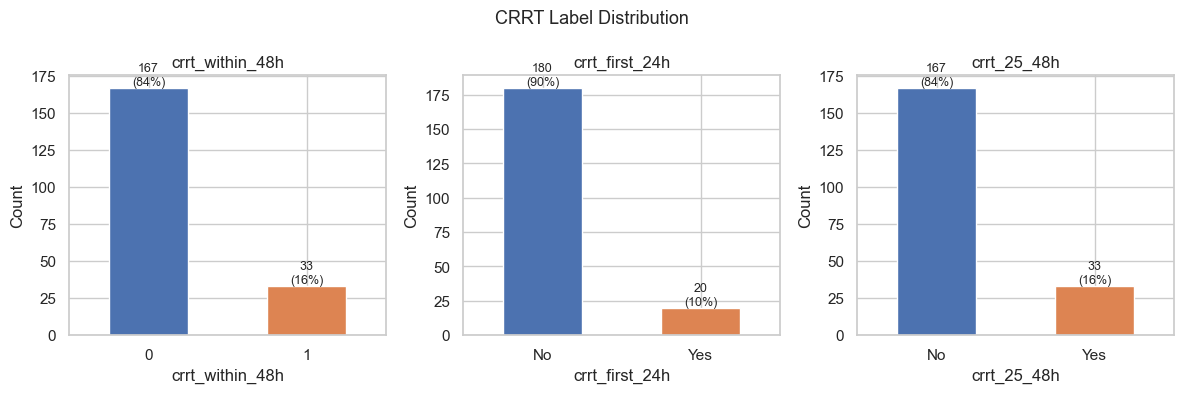


Positive rate (crrt_within_48h): 16.5%
Class imbalance ratio (neg:pos): 5.1:1


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, ['crrt_within_48h', 'crrt_first_24h', 'crrt_25_48h']):
    # crrt_within_48h is numeric (0/1); the source cols are Yes/No strings
    vals = df[col] if col == 'crrt_within_48h' else raw_df[col]
    counts = vals.value_counts(dropna=False)
    counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], rot=0, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}\n({p.get_height()/len(vals)*100:.0f}%)',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('CRRT Label Distribution', fontsize=13)
plt.tight_layout()
plt.show()

pos_rate = df[TARGET_COL].mean()
print(f'\nPositive rate (crrt_within_48h): {pos_rate:.1%}')
print(f'Class imbalance ratio (neg:pos): {(1-pos_rate)/pos_rate:.1f}:1')

## 4. Raw Feature Distributions by CRRT Status
Key clinical inputs split by `crrt_within_48h`.

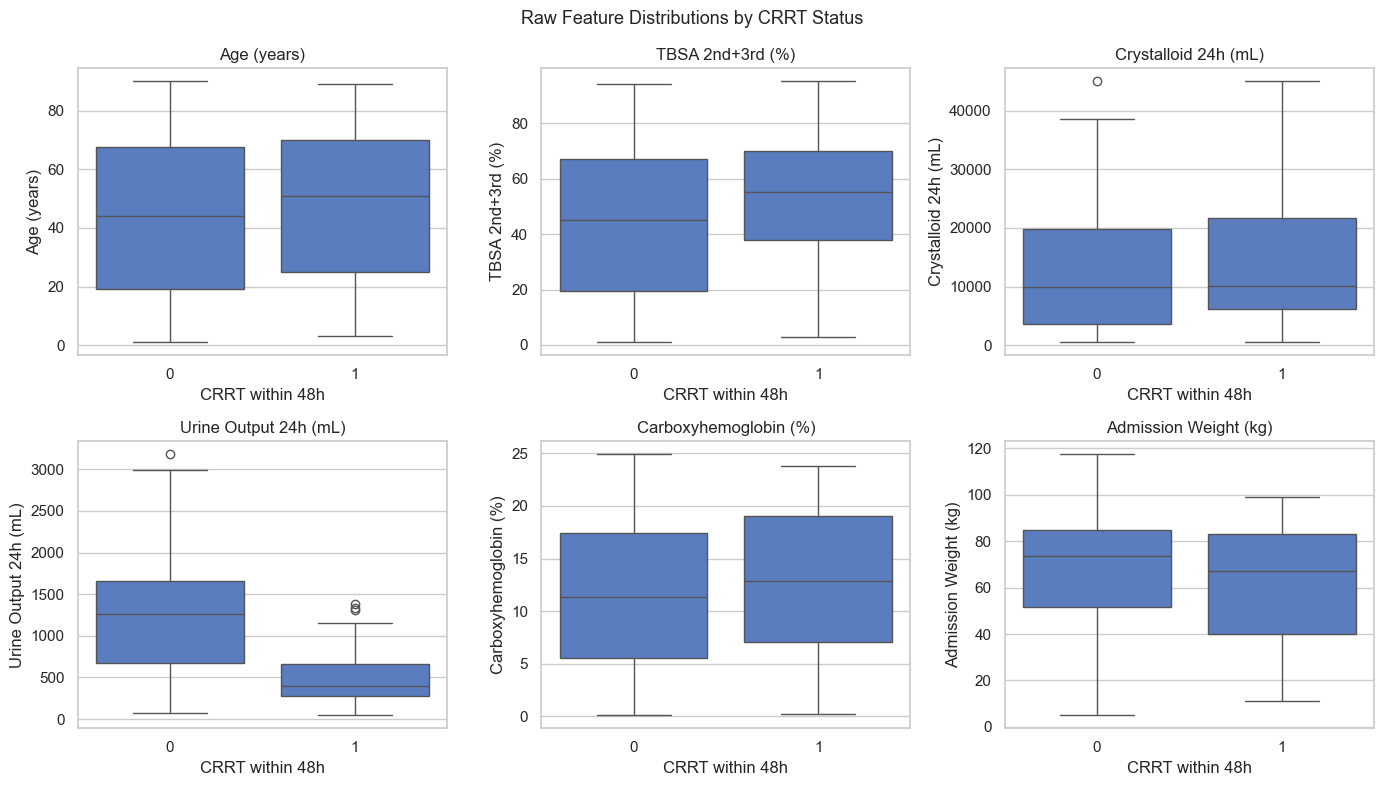

In [14]:
continuous_raw = [
    ('age', 'Age (years)'),
    ('tbsa_2nd_3rd', 'TBSA 2nd+3rd (%)'),
    ('total_crystalloid_ml_first_24h', 'Crystalloid 24h (mL)'),
    ('total_urine_output_ml_first_24h', 'Urine Output 24h (mL)'),
    ('carboxyhemoglobin', 'Carboxyhemoglobin (%)'),
    ('admission_weight_kg', 'Admission Weight (kg)'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
target_numeric = df[TARGET_COL].dropna().astype(int)

for ax, (col, label) in zip(axes.flat, continuous_raw):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    plot_df = pd.DataFrame({'value': pd.to_numeric(df[col], errors='coerce'), 'crrt': df[TARGET_COL]})
    plot_df = plot_df.dropna()
    sns.boxplot(data=plot_df, x='crrt', y='value', ax=ax)
    ax.set_xlabel('CRRT within 48h')
    ax.set_ylabel(label)
    ax.set_title(label)

plt.suptitle('Raw Feature Distributions by CRRT Status', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Engineered Feature Analysis
These are the exact features the XGBoost model receives after `engineer_features()`.

In [16]:
# Split into binary flags and continuous features
binary_flags = [c for c in FEATURE_COLS if df[c].dropna().isin([0, 1]).all()]
continuous_eng = [c for c in FEATURE_COLS if c not in binary_flags]
print(f'Binary flag features:     {binary_flags}')
print(f'Continuous/ordinal features: {continuous_eng}')
# Summary stats for all engineered features
display(df[FEATURE_COLS].describe().T.round(3))

Binary flag features:     ['inhalation_flag', 'late_admission_flag', 'fluid_overload_flag', 'carboxyhemoglobin_risk_flag', 'hypothermia_flag', 'low_urine_output_flag']
Continuous/ordinal features: ['age', 'tbsa_2nd_3rd', 'revised_baux_score', 'hours_injury_to_admission', 'fluid_balance_24h', 'burn_severity_tier', 'urine_output_per_kg', 'comorbidity_aki_risk_score']


,count,mean,std,min,25%,50%,75%,max
age,200.0,44.505,26.804,1.000,19.000,44.500,68.250,90.000
tbsa_2nd_3rd,200.0,46.025,26.648,1.000,21.000,47.000,68.250,95.000
inhalation_flag,200.0,0.465,0.500,0.000,0.000,0.000,1.000,1.000
revised_baux_score,200.0,98.435,39.655,14.000,70.750,97.500,128.250,192.000
hours_injury_to_admission,200.0,19.320,10.523,1.000,9.000,19.000,28.000,36.000
late_admission_flag,200.0,0.860,0.348,0.000,1.000,1.000,1.000,1.000
fluid_balance_24h,200.0,11330.645,9862.922,-997.000,3149.250,8711.000,18198.250,44209.000
fluid_overload_flag,200.0,0.920,0.272,0.000,1.000,1.000,1.000,1.000
burn_severity_tier,200.0,1.485,0.961,0.000,1.000,1.000,2.000,3.000
urine_output_per_kg,200.0,17.130,7.076,2.326,12.522,17.232,21.907,35.652


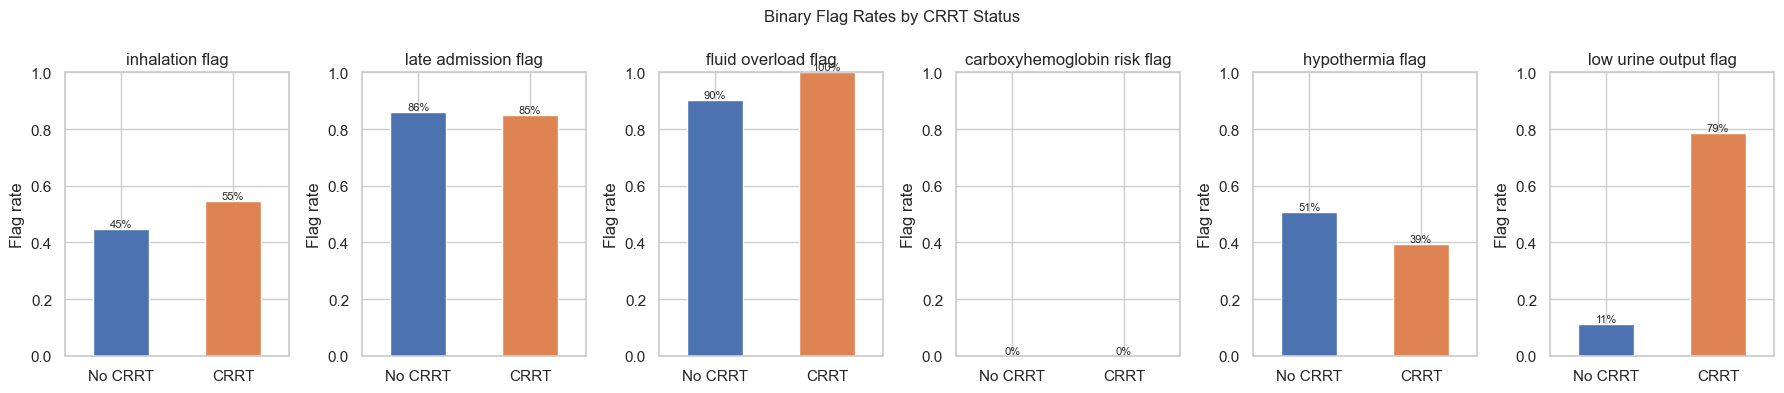

In [17]:
# Binary flag rates overall and by CRRT status
if binary_flags:
    fig, axes = plt.subplots(1, len(binary_flags), figsize=(3 * len(binary_flags), 4))
    if len(binary_flags) == 1:
        axes = [axes]
    for ax, col in zip(axes, binary_flags):
        flag_by_crrt = df.groupby(TARGET_COL)[col].mean().rename({0: 'No CRRT', 1: 'CRRT'})
        flag_by_crrt.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], rot=0, edgecolor='white')
        ax.set_title(col.replace('_', ' '))
        ax.set_ylabel('Flag rate')
        ax.set_ylim(0, 1)
        ax.set_xlabel('')
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.0%}',
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha='center', va='bottom', fontsize=8)
    plt.suptitle('Binary Flag Rates by CRRT Status', fontsize=12)
    plt.tight_layout()
    plt.show()

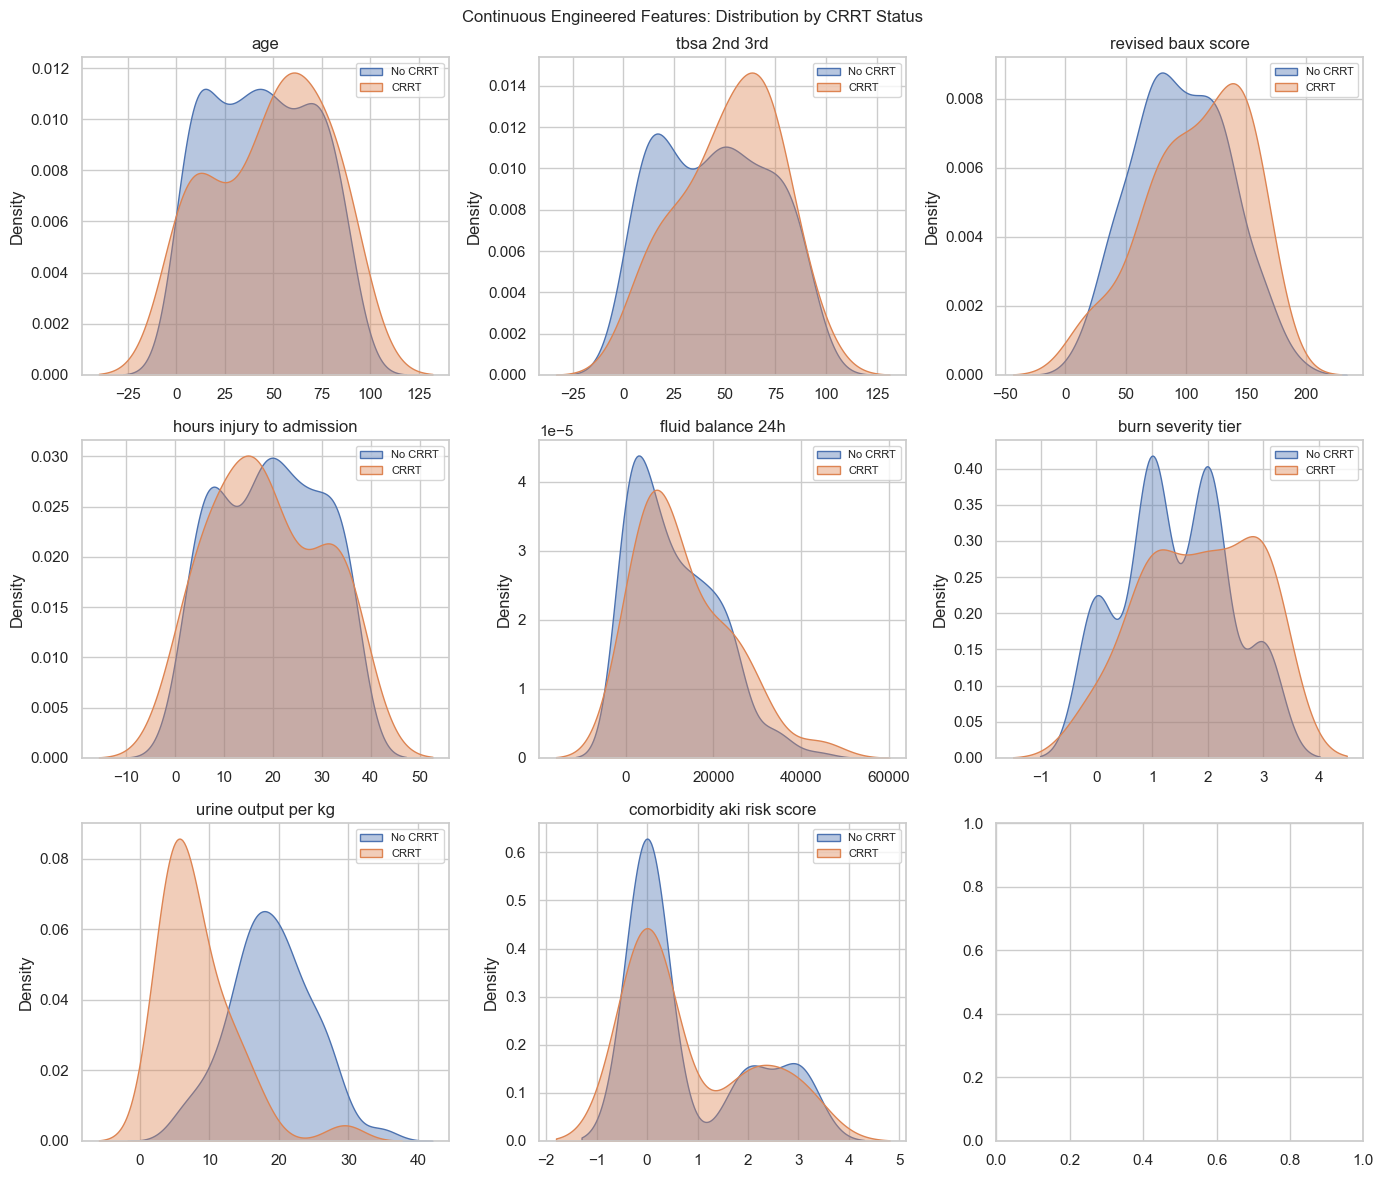

In [18]:
# Continuous/ordinal engineered features by CRRT status
if continuous_eng:
    ncols = 3
    nrows = -(-len(continuous_eng) // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

    for ax, col in zip(axes_flat, continuous_eng):
        plot_df = pd.DataFrame({
            'value': pd.to_numeric(df[col], errors='coerce'),
            'crrt': df[TARGET_COL]
        }).dropna()
        sns.kdeplot(data=plot_df[plot_df['crrt'] == 0], x='value', ax=ax,
                    label='No CRRT', fill=True, alpha=0.4, color='#4C72B0')
        sns.kdeplot(data=plot_df[plot_df['crrt'] == 1], x='value', ax=ax,
                    label='CRRT', fill=True, alpha=0.4, color='#DD8452')
        ax.set_title(col.replace('_', ' '))
        ax.set_xlabel('')
        ax.legend(fontsize=8)

    # Hide unused subplots
    for ax in list(axes_flat)[len(continuous_eng):]:
        ax.set_visible(False)

    plt.suptitle('Continuous Engineered Features: Distribution by CRRT Status', fontsize=12)
    plt.tight_layout()
    plt.show()

## 6. Correlation of Engineered Features with Target
Point-biserial correlation between each feature and `crrt_within_48h`.
Higher absolute value = stronger linear association with the label.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5405: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rpb, prob = pearsonr(x, y)


,feature,correlation,p_value
13,low_urine_output_flag,0.599,0.0000
9,urine_output_per_kg,-0.557,0.0000
8,burn_severity_tier,0.168,0.0171
7,fluid_overload_flag,0.131,0.0643
3,revised_baux_score,0.122,0.0840
1,tbsa_2nd_3rd,0.101,0.1529
11,hypothermia_flag,-0.085,0.2291
6,fluid_balance_24h,0.078,0.2694
2,inhalation_flag,0.072,0.3130
0,age,0.058,0.4178


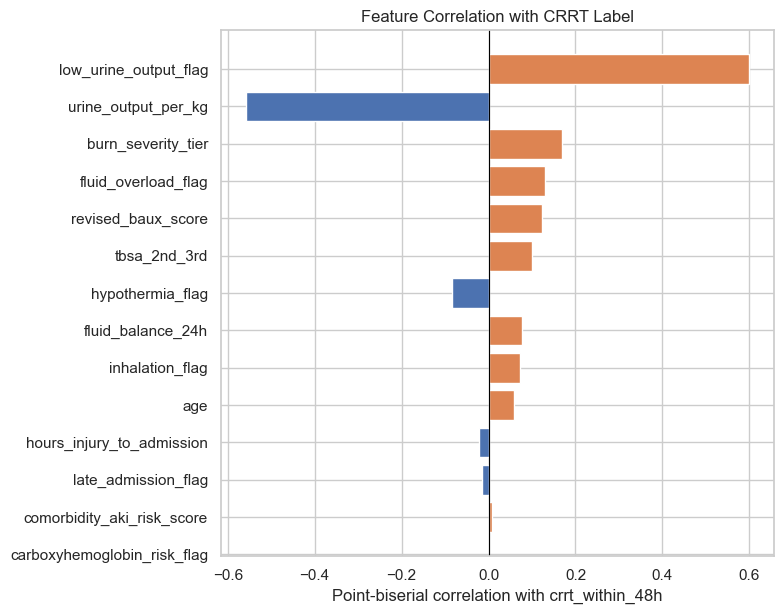

In [19]:
from scipy import stats

corr_rows = []
target_series = df[TARGET_COL].dropna().astype(float)

for col in FEATURE_COLS:
    if col not in df.columns:
        continue
    feat = pd.to_numeric(df[col], errors='coerce')
    mask = feat.notna() & target_series.notna()
    if mask.sum() < 10:
        continue
    r, p = stats.pointbiserialr(target_series[mask], feat[mask])
    corr_rows.append({'feature': col, 'correlation': round(r, 3), 'p_value': round(p, 4)})

corr_df = pd.DataFrame(corr_rows).sort_values('correlation', key=abs, ascending=False)
display(corr_df)

fig, ax = plt.subplots(figsize=(8, max(4, len(corr_df) * 0.45)))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_df['correlation']]
ax.barh(corr_df['feature'], corr_df['correlation'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-biserial correlation with crrt_within_48h')
ax.set_title('Feature Correlation with CRRT Label')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Feature Correlation Heatmap
Pairwise Pearson correlation among all engineered features.

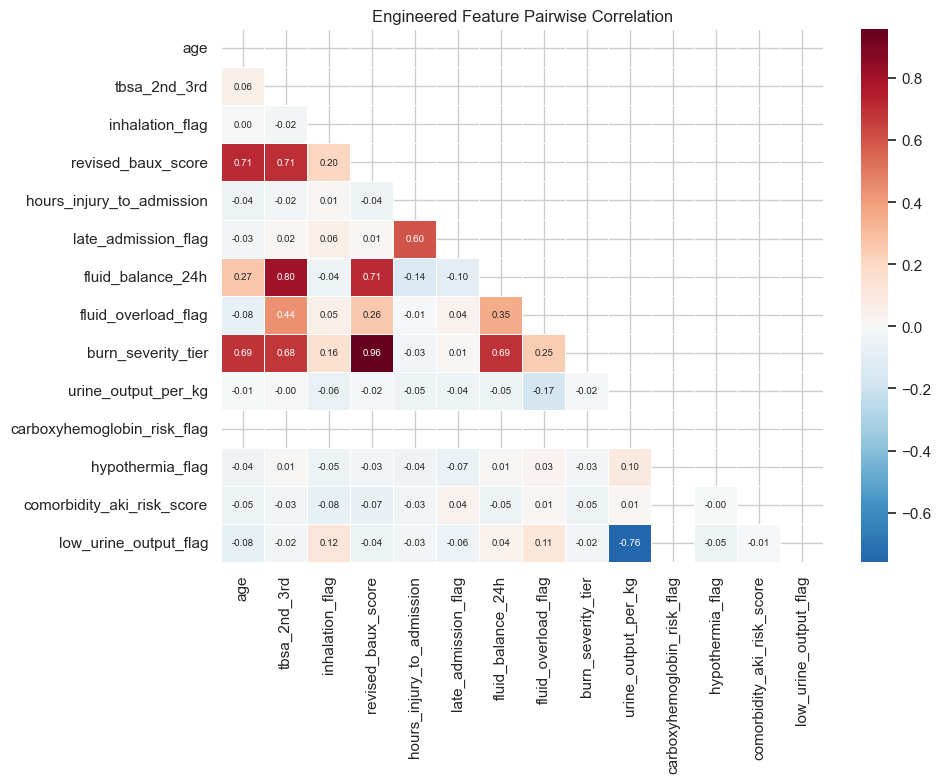

In [20]:
feat_df = df[FEATURE_COLS].apply(pd.to_numeric, errors='coerce')
corr_matrix = feat_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Engineered Feature Pairwise Correlation')
plt.tight_layout()
plt.show()

## 8. Demographic Overview

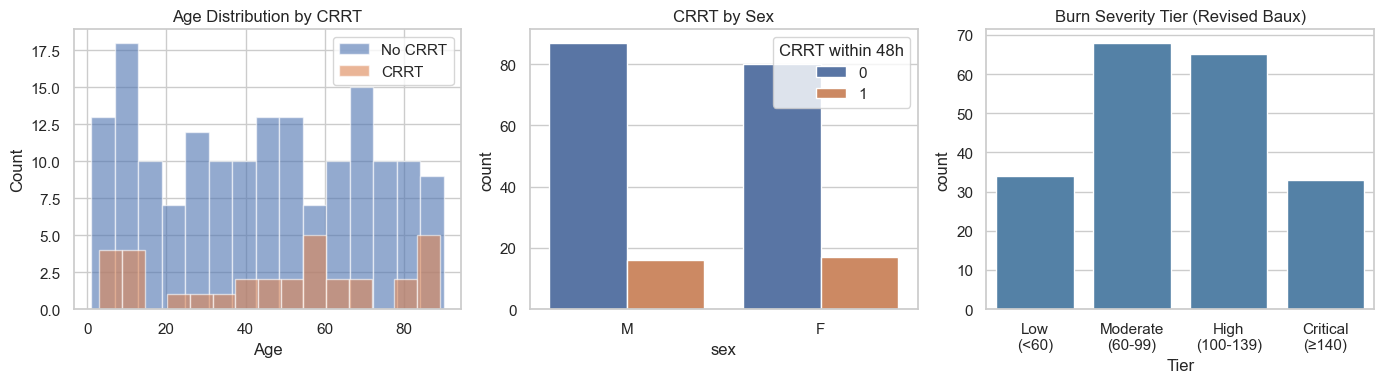

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age histogram by CRRT status
for crrt_val, label, color in [(0, 'No CRRT', '#4C72B0'), (1, 'CRRT', '#DD8452')]:
    subset = df[df[TARGET_COL] == crrt_val]['age'].dropna()
    axes[0].hist(subset, bins=15, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0].set_title('Age Distribution by CRRT')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# CRRT by sex
sex_crrt = raw_df.copy()
sex_crrt[TARGET_COL] = df[TARGET_COL]
sns.countplot(data=sex_crrt, x='sex', hue=TARGET_COL,
              ax=axes[1], palette={0: '#4C72B0', 1: '#DD8452'})
axes[1].set_title('CRRT by Sex')
axes[1].legend(title='CRRT within 48h')

# Burn severity tier distribution
tier_labels = {0: 'Low\n(<60)', 1: 'Moderate\n(60-99)', 2: 'High\n(100-139)', 3: 'Critical\n(≥140)'}
tier_data = df['burn_severity_tier'].map(tier_labels)
tier_order = list(tier_labels.values())
sns.countplot(x=tier_data, order=[t for t in tier_order if t in tier_data.values],
              ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Burn Severity Tier (Revised Baux)')
axes[2].set_xlabel('Tier')

plt.tight_layout()
plt.show()